# Group Project — World Happiness Report
## Research Methods for Business Analytics

**Dataset:** World Happiness Report  
**Course:** Research Methods for Business Analytics  
**Group:** TXA - A17

**Group Members:**
- 82715, Fabio Barbagallo
- 81204, Fabrice Keraudren
- 81245, Giacomo Aleotti 

## Table of Contents

1. [Project Overview](#1.-project-overview)
2. [Executive Summary](#2.-executive-summary)
3. [Introduction](#3.-introduction)
   - 3.1 [Data Source and Importing](#3.1-data-source-and-importing)
   - 3.2 [Variable Definitions](#3.2-variable-definitions)
4. [Data Cleaning](#4-data-cleaning)
   - 4.1 [Standardizing Column Names and Combining Datasets](#41-standardizing-column-names-and-combining-datasets)
   - 4.2 [Country Coverage](#42-country-coverage)
   - 4.3 [Missing Values](#43-missing-values)
   - 4.4 [Duplicates](#44-duplicates)
   - 4.5 [Outliers](#45-outliers)
5. [Exploratory Data Analysis](#5-exploratory-data-analysis)
   - 5.1 [Types of Variables](#51-types-of-variables)
   - 5.2 [Descriptive Statistics](#52-descriptive-statistics)
     - 5.2.1 [Frequencies](#521-frequencies)
     - 5.2.2 [Central Tendency and Spread](#522-central-tendency-and-spread)
     - 5.2.3 [Distribution and Extreme Values](#523-distribution-and-extreme-values)
     - 5.2.4 [Summary Statistics Table](#524-summary-statistics-table)
   - 5.3 [Relationships between Variables](#53-relationships-between-variables)
     - 5.3.1 [Scatterplots](#531-scatterplots)
     - 5.3.2 [Covariance](#532-covariance)
     - 5.3.3 [Pearson and Spearman Correlations](#533-pearson-and-spearman-correlations)
     - 5.3.4 [Correlation Heatmap](#534-correlation-heatmap)
     - 5.3.5 [Regional Patterns](#535-regional-patterns)
   - 5.4 [Patterns across Reports](#54-patterns-across-reports)
     - 5.4.1 [Matched 2015–2019 Subset](#541-matched-20152019-subset)
     - 5.4.2 [Distribution of Happiness Change](#542-distribution-of-happiness-change)
     - 5.4.3 [Geographic Distribution of Happiness Change](#543-geographic-distribution-of-happiness-change)
6. [Research Question and Hypotheses](#6-research-question-and-hypotheses)
   - 6.1 [Research Question](#61-research-question)
   - 6.2 [Hypotheses](#62-hypotheses)
   - 6.3 [Constructed Variables for Factor Profile Hypothesis Testing](#63-constructed-variables-for-factor-profile-hypothesis-testing)
7. [Method 1: Correlation Analysis - Factor Balance](#7-method-1-correlation-analysis---factor-balance)
   - 7.1 [Why this method](#71-why-this-method)
   - 7.2 [Visual Inspection](#72-visual-inspection)
   - 7.3 [Pearson and Spearman Correlations](#73-pearson-and-spearman-correlations)
   - 7.4 [Robustness Check](#74-robustness-check)
   - 7.5 [Conclusion on Hypothesis 1](#75-conclusion-on-hypothesis-1)
8. [Method 2: Multiple Linear Regression - Weakest-Link Effect](#8-method-2-multiple-linear-regression---weakest-link-effect)
   - 8.1 [Why this method](#81-why-this-method)
   - 8.2 [Incremental Regression Model comparison](#82-incremental-regression-model-comparison)
   - 8.3 [Regression Assumptions](#833-normality-of-residuals)
   - 8.4 [Robust Regression Results](#84-robust-regression-results)
   - 8.5 [Conclusion on Hypothesis 2](#85-conclusion-on-hypothesis-2)
9. [Interpretation, Conclusion and Limitations](#9-interpretation-conclusion-and-limitations)
   - 9.1 [Interpretation of findings](#91-interpretation-of-findings)
   - 9.2 [Conclusion](#92-conclusion)
   - 9.3 [Limitations and possible improvements](#93-limitations-and-possible-improvements)
10. [Reflection on the use of AI](#10-reflection-on-the-use-of-ai)
11. [References](#11-references)

## 1. Project Overview

The goal of this project is to apply statistical methods from the Research Methods for Business Analytics course to a real-world dataset.

We use the World Happiness Report dataset (https://www.kaggle.com/datasets/unsdsn/world-happiness), covering the 2015–2019 report editions, to investigate patterns and differences in national happiness and their relationship with the factors used in the World Happiness Report framework.

The project will:

1. explore and understand the dataset,
2. clean and prepare the data for analysis,
3. perform exploratory data analysis,
4. formulate a research question and testable hypotheses based on the exploratory findings,
5. test the hypotheses using two different statistical methods,
6. interpret the results, and
7. discuss limitations and possible improvements.

The research question and the two statistical methods were chosen after the exploratory analysis, based on patterns observed in the data.

## 2. Executive Summary

This project examines whether changes in national happiness between the 2015 and 2019 World Happiness Report editions are associated with the **configuration of a country’s happiness-related factor profile**, rather than with individual factors alone. The analysis focuses on two characteristics of the six factor contributions: the **balance** of the overall profile and the strength of its **weakest factor**.

The analysis uses a matched sample of **152 countries** observed in both the 2015 and 2019 report editions. The six factor contributions were standardized within the 2015 data and used to construct three measures: `factor_balance`, `weakest_factor`, and `overall_factor_level`. Subsequent happiness change was measured as the difference between the 2019 and 2015 happiness scores.

For **Hypothesis 1**, Pearson and Spearman correlations were used to test whether more balanced factor profiles were associated with more favourable happiness changes. Both relationships were close to zero and statistically non-significant (Pearson r = −0.037, p = 0.655; Spearman ρ = −0.024, p = 0.768). A Welch t-test comparing more versus less balanced countries produced the same conclusion (p = 0.798).

For **Hypothesis 2**, multiple linear regression was used, controlling for the overall factor level and for the 2015 happiness score. The weakest-factor effect is invisible in models without the initial score, but becomes positive and just significant once regression to the mean is accounted for (β = 0.216, HC3 p = 0.049, 95% CI [0.001, 0.431]). The estimate is stable across specifications but marginal, and it loses significance when the most influential country (Venezuela) is removed.

Overall, **the configuration of the 2015 factor profile explains little of the subsequent change in happiness: balance does not matter, and a single weak factor in the profile matters only modestly**, with tentative evidence. The dominant predictor of change is a country's starting level. The findings should be interpreted cautiously because the factor variables are model-derived contributions and the report editions use multi-year averages.

## 3. Introduction

Happiness and life satisfaction differ considerably across countries and may be related to a range of economic, social, health, and institutional conditions. The World Happiness Report provides international data on people's evaluations of their lives and is widely used to compare well-being across countries.

This project uses data from the 2015–2019 editions of the World Happiness Report. The central outcome variable is the happiness_score, which is based on the Cantril Ladder, where respondents evaluate their current life on a scale from 0 (worst possible life) to 10 (best possible life).

The dataset also contains six factors used by the World Happiness Report to explain differences in national life evaluations: economic conditions, social support, healthy life expectancy, freedom to make life choices, generosity, and perceptions of corruption. Importantly, the values provided for these factors in the Kaggle dataset are model-derived contributions to explaining the happiness score, rather than simple raw measurements of the underlying variables.

The 2015–2019 files represent different editions of the World Happiness Report rather than independent observations from single calendar years. The reported country scores are generally based on multi-year averages, which must be considered when analysing changes over time.

Before defining the final research question and hypotheses, we first explore and prepare the dataset to understand its structure, variables, country coverage, missing values, distributions, and patterns over time.

### 3.1 Data Source and Importing

The dataset (available on Kaggle: https://www.kaggle.com/datasets/unsdsn/world-happiness) contains separate CSV files for the 2015–2019 World Happiness Report editions. Each file contains country-level happiness scores together with several factors used in the World Happiness Report framework.

Because the column names and dataset structure differ across report editions, we first import the five files separately and inspect their column names before combining them into a consistent dataset.

In [208]:
# import all the packages used
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from scipy import stats
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson

In [209]:

# import the 5 report editions individually
df_2015 = pd.read_csv("data/2015.csv")
df_2016 = pd.read_csv("data/2016.csv")
df_2017 = pd.read_csv("data/2017.csv")
df_2018 = pd.read_csv("data/2018.csv")
df_2019 = pd.read_csv("data/2019.csv")

# print the column names for each dataset
print("2015:", df_2015.columns.tolist())
print("2016:", df_2016.columns.tolist())
print("2017:", df_2017.columns.tolist())
print("2018:", df_2018.columns.tolist())
print("2019:", df_2019.columns.tolist())

2015: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2016: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Lower Confidence Interval', 'Upper Confidence Interval', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']
2017: ['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.', 'Family', 'Health..Life.Expectancy.', 'Freedom', 'Generosity', 'Trust..Government.Corruption.', 'Dystopia.Residual']
2018: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
2019: ['Overall rank', 'Country or region', 'Score', 'GDP per capita', 'Social sup

### 3.2 Variable Definitions

The World Happiness Report datasets contain national happiness scores and several factors used to explain differences in life evaluations across countries. As the available columns differ slightly across report editions, we will later harmonize the variable names. Importantly, the six explanatory variables in the Kaggle dataset represent estimated factor contributions rather than raw measurements of the underlying characteristics.

- year: Added manually and refers to the World Happiness Report edition (2015–2019). It does not necessarily represent a single measurement year, as happiness scores are generally based on multi-year survey averages.
- country: Country or territory included in the respective World Happiness Report.
- happiness_score: Main outcome variable. It represents the average national life evaluation based on the Gallup World Poll's Cantril Ladder, ranging from 0 (worst possible life) to 10 (best possible life).
- happiness_rank: A country's relative position within the respective report edition based on its happiness score. The happiness score is preferred for statistical analysis because ranks do not represent equal numerical differences.

The following six variables represent the estimated contribution of each factor to explaining why a country's life evaluation is higher than that of the hypothetical benchmark country, Dystopia:

- gdp_per_capita: Economic contribution, based on log GDP per capita adjusted for purchasing power differences.
- social_support: Contribution of social support, based on whether respondents have relatives or friends they can rely on in times of trouble.
- healthy_life_expectancy: Contribution of healthy life expectancy at birth.
- freedom: Contribution of satisfaction with the perceived freedom to make important life choices.
- generosity: Contribution of generosity, based on reported charitable donations adjusted for GDP per capita.
- corruption_perception: Contribution associated with lower perceived corruption in government and business. Higher values therefore indicate a more favourable contribution from this factor.

These contributions help explain differences in national life evaluations but do not directly determine or generate the observed happiness score.

## 4. Data Cleaning

The goal of this section is to prepare the initial combined dataset for further exploratory analysis steps as well as the statistical analyses.

### 4.1 Standardizing Column Names and Combining Datasets

The five yearly datasets use slightly different column names and structures. To analyse them together, we first harmonize the names of the variables that are available across all five editions.

We then add a 'year' variable for every observation indicating the respective World Happiness Report edition and combine the five datasets into one dataset.

In [210]:
# create a mapping of the column names to a single unified convention
column_map = {
    "Country": "country",
    "Country or region": "country",

    "Region": "region",

    "Happiness Rank": "happiness_rank",
    "Happiness.Rank": "happiness_rank",
    "Overall rank": "happiness_rank",

    "Happiness Score": "happiness_score",
    "Happiness.Score": "happiness_score",
    "Score": "happiness_score",

    "Economy (GDP per Capita)": "gdp_per_capita",
    "Economy..GDP.per.Capita.": "gdp_per_capita",
    "GDP per capita": "gdp_per_capita",

    "Family": "social_support",
    "Social support": "social_support",

    "Health (Life Expectancy)": "healthy_life_expectancy",
    "Health..Life.Expectancy.": "healthy_life_expectancy",
    "Healthy life expectancy": "healthy_life_expectancy",

    "Freedom": "freedom",
    "Freedom to make life choices": "freedom",

    "Trust (Government Corruption)": "corruption_perception",
    "Trust..Government.Corruption.": "corruption_perception",
    "Perceptions of corruption": "corruption_perception",

    "Generosity": "generosity"
}

# rename all the columns in the datasets
df_2015 = df_2015.rename(columns=column_map)
df_2016 = df_2016.rename(columns=column_map)
df_2017 = df_2017.rename(columns=column_map)
df_2018 = df_2018.rename(columns=column_map)
df_2019 = df_2019.rename(columns=column_map)

# add an empty region column for the datasets (2017, 2018, 2019) where region is not available
for dataset in [df_2015, df_2016, df_2017, df_2018, df_2019]:
    if "region" not in dataset.columns:
        dataset["region"] = pd.NA

# the identified common columns are the following
common_columns = [
    "year", # identifies the year of the report
    "country",
    "region",
    "happiness_rank",
    "happiness_score",
    "gdp_per_capita",
    "social_support",
    "healthy_life_expectancy",
    "freedom",
    "corruption_perception",
    "generosity"
]

# add the column year for each dataset as seperate column "year"
df_2015["year"] = 2015
df_2016["year"] = 2016
df_2017["year"] = 2017
df_2018["year"] = 2018
df_2019["year"] = 2019

# putting all the datasets together into one dataset
df = pd.concat([
    df_2015[common_columns],
    df_2016[common_columns],
    df_2017[common_columns],
    df_2018[common_columns],
    df_2019[common_columns]
], ignore_index=True)

# print the shape (number of rows and columns) of df
print("Shape:", df.shape)

# print the first 5 rows of the combined dataset
df.head()

Shape: (782, 11)


,year,country,region,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
0,2015,Switzerland,Western Europe,1,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678
1,2015,Iceland,Western Europe,2,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630
2,2015,Denmark,Western Europe,3,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139
3,2015,Norway,Western Europe,4,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699
4,2015,Canada,North America,5,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811


In [211]:
# display the data types of each column in the combined dataset
df.dtypes

year                         int64
country                     object
region                      object
happiness_rank               int64
happiness_score            float64
gdp_per_capita             float64
social_support             float64
healthy_life_expectancy    float64
freedom                    float64
corruption_perception      float64
generosity                 float64
dtype: object

### 4.2 Country Coverage

The combined dataset contains observations from five report editions, but not all countries are included in every edition. Also, some inconsistencies exist in the country naming conventions across different years (e.g., "Hong Kong" vs "Hong Kong S.A.R., China"). We therefore standardize country names before examining country coverage. We also use the region information available in the earlier report editions (2015-2016) to assign a consistent region to countries in later editions (2017-2019).

In [212]:
# number of observations in each report
df["year"].value_counts().sort_index()

year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

In [213]:
# get the country names and remove any leading or trailing whitespaces
df["country"] = df["country"].str.strip() 

# check in which report editions each country name appears
years_per_country = df.groupby("country")["year"].apply(list) 

# identify country names that do not appear in all five report editions
incomplete = years_per_country[years_per_country.apply(len) < 5] 

print("distinct countries before harmonization:", df["country"].nunique())
print("Country names not present in all five editions:", len(incomplete), "\n")
print(incomplete.to_string())

distinct countries before harmonization: 170
Country names not present in all five editions: 29 

country
Angola                      [2015, 2016, 2017, 2018]
Belize                            [2016, 2017, 2018]
Central African Republic    [2015, 2017, 2018, 2019]
Comoros                           [2015, 2016, 2019]
Djibouti                                      [2015]
Gambia                                        [2019]
Hong Kong                   [2015, 2016, 2018, 2019]
Hong Kong S.A.R., China                       [2017]
Laos                        [2015, 2016, 2018, 2019]
Lesotho                     [2015, 2017, 2018, 2019]
Macedonia                   [2015, 2016, 2017, 2018]
Mozambique                  [2015, 2017, 2018, 2019]
Namibia                     [2016, 2017, 2018, 2019]
North Cyprus                      [2015, 2016, 2017]
North Macedonia                               [2019]
Northern Cyprus                         [2018, 2019]
Oman                                          

some countries appear twice in this list, because the naming is inconsistent across the years. We will standardize this in the following step.

In [214]:
# map each alternative spelling to one standard name
country_names = {
    "Hong Kong S.A.R., China": "Hong Kong",
    "Taiwan Province of China": "Taiwan",
    "Trinidad & Tobago": "Trinidad and Tobago",
    "North Cyprus": "Northern Cyprus",
    "Macedonia": "North Macedonia",
    "Somaliland Region": "Somaliland region",
    "Ivory Coast": "Cote d'Ivoire", # change mapping so it is correctly displayed on the map later
}
# overwrite the country names with the standardized names
df["country"] = df["country"].replace(country_names)

In [215]:
# check the country coverage again after standardizing the country names
years_per_country = df.groupby("country")["year"].nunique()

# countries that are not present in all five report editions
incomplete = years_per_country[years_per_country < 5]

print("Distinct countries after standardization:", df["country"].nunique())
print("Countries present in all five years:", (years_per_country == 5).sum())
print("Countries not present in all five years:", len(incomplete))

# check: standardizing names must not create duplicates
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())

Distinct countries after standardization: 164
Countries present in all five years: 146
Countries not present in all five years: 18
Duplicated country-year pairs: 0


Now that we have harmonized the country names and do not have any duplicates, we will continue by assigning regions to later report editions using the region information available in the 2015 and 2016 datasets. Finally, we will check the country coverage for the combined dataset.

In [216]:
# create a country-region lookup from observations where region is available
region_map = (
    df.dropna(subset=["region"])
      .drop_duplicates(subset="country")
      .set_index("country")["region"]
)

# fill missing region values using the country-region lookup
df["region"] = df["region"].fillna(df["country"].map(region_map))

In [217]:
# check whether any countries still have no region assigned
missing_regions = df.loc[df["region"].isna(), "country"].unique()

print("Countries without region:", len(missing_regions))
print(missing_regions)

Countries without region: 1
['Gambia']


In [218]:
# Gambia has no assigned region from a previous report edition, therefore we will manually assign it to the "Sub-Saharan Africa" region
df.loc[df["country"] == "Gambia", "region"] = "Sub-Saharan Africa"

Now, we can print the final Country Coverage statistics

In [1]:
# final country coverage summary
years_per_country = df.groupby("country")["year"].nunique()

print("Total unique countries:", df["country"].nunique())
print("Countries present in all five report editions:", (years_per_country == 5).sum())
print("Countries not present in all five report editions:", (years_per_country < 5).sum())
print("Missing regions:", df["region"].isna().sum())

print("\nUnique countries per region:")
print(df.groupby("region")["country"].nunique().sort_values(ascending=False))

NameError: name 'df' is not defined

After standardizing country names, the dataset contains 164 unique countries, of which 146 appear in all five report editions. The remaining 18 countries are retained and can be filtered later if required. All observations have been assigned to one of the World Happiness Report regions.

### 4.3 Missing Values

Before further analyzing the variables in descriptive statistics, we check whether the combined dataset contains missing values. Missing observations are important because they may affect which variables can be used in the later statistical analysis.

In [220]:
# check the number of missing values for each variable
df.isna().sum()

year                       0
country                    0
region                     0
happiness_rank             0
happiness_score            0
gdp_per_capita             0
social_support             0
healthy_life_expectancy    0
freedom                    0
corruption_perception      1
generosity                 0
dtype: int64

In [221]:
# identify which observation contains the missing value
df[df.isna().any(axis=1)]

,year,country,region,happiness_rank,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
489,2018,United Arab Emirates,Middle East and Northern Africa,20,6.774,2.096,0.776,0.67,0.284,NaN,0.186


The dataset contains one missing value for the corruption_perception for the UAE in the 2018 report.

Based on the available dataset, we cannot determine why this value is missing or classify the mechanism as MCAR, MAR, or MNAR. It may be MNAR (Missing Not At Random), because the government of the UAE did not want to publish the data for this metric in that year. 

Since only one observation is affected, we leave the value as missing rather than estimating it (e.g. using interpolation of the neighbouring years, or using the mean). It is methodologically cleaner to omit this value later if the statistical methods require it, instead of trying to artificially impute it.

In [222]:
# show the missing value in the timeline
uae = df[df["country"] == "United Arab Emirates"]
print(uae[["country", "year", "corruption_perception"]].to_string(index=False))

             country  year  corruption_perception
United Arab Emirates  2015                0.38583
United Arab Emirates  2016                0.35561
United Arab Emirates  2017                0.32449
United Arab Emirates  2018                    NaN
United Arab Emirates  2019                0.18200


### 4.4 Duplicates

After standardizing the country names, we check whether the combined dataset contains duplicated rows or multiple observations for the same country within the same report. Such duplicates could bias later summary statistics and statistical analyses.

In [ ]:
# completely identical rows
print("Identical rows               :", df.duplicated().sum())

# the same country more than once in the same year
print("Duplicated country-year pairs:", df.duplicated(subset=["country", "year"]).sum())

Identical rows               : 0
Duplicated country-year pairs: 0


No duplicated rows or duplicated country-year observations were found. Each country therefore appears at most once within each report edition.

### 4.5 Outliers

Before starting the exploratory analysis, we check the dataset for values that would be logically inconsistent. Happiness scores should remain within the 0–10 range, the factor contributions in these datasets should not be negative, and countries with a better happiness rank within the same report edition should not have a lower happiness score than countries ranked below them.

No impossible values or rank-score inconsistencies were found. We proceed in three steps: impossible values, extreme values according to the IQR rule, and a panel-specific check of each country's consistency over time.

In [224]:
# Define the six factor variables
factor_cols = ["gdp_per_capita", "social_support", "healthy_life_expectancy", 
               "freedom", "corruption_perception", "generosity"]

# 4.5.1 impossible values: check every variable against its logical range
print("Score outside 0-10    :", ((df["happiness_score"] < 0) | (df["happiness_score"] > 10)).sum())
print("Negative factor values:", (df[factor_cols] < 0).sum().sum())

# within each year, a better rank must never come with a lower score
ranked = df.sort_values(["year", "happiness_rank"])
score_change = ranked.groupby("year")["happiness_score"].diff()
print("Rank/score inconsistencies:", (score_change > 0.0005).sum())

Score outside 0-10    : 0
Negative factor values: 0
Rank/score inconsistencies: 0


All values are within their logical ranges and the ranks are consistent with the scores. There are no impossible values.

In [225]:
# 4.5.2 extreme values: number of outliers according to the 1.5 x IQR rule, plus skewness
variables = ["happiness_score"] + factor_cols

outlier_table = []
for variable in variables:
    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1
    n_low = (df[variable] < q1 - 1.5 * iqr).sum()
    n_high = (df[variable] > q3 + 1.5 * iqr).sum()
    outlier_table.append([variable, n_low, n_high, round(df[variable].skew(), 2)])

outlier_table = pd.DataFrame(outlier_table, columns=["variable", "low outliers", "high outliers", "skewness"])
print(outlier_table.to_string(index=False))

# who are the most extreme observations?
print(df.sort_values("corruption_perception", ascending=False)[["country", "year", "corruption_perception"]].head(5).to_string(index=False))
print(df.sort_values("generosity", ascending=False)[["country", "year", "generosity"]].head(5).to_string(index=False))

               variable  low outliers  high outliers  skewness
        happiness_score             0              0      0.04
         gdp_per_capita             0              0     -0.32
         social_support            10              0     -0.68
healthy_life_expectancy             0              0     -0.50
                freedom             0              0     -0.52
  corruption_perception             0             67      1.52
             generosity             0             17      1.04
  country  year  corruption_perception
   Rwanda  2015                0.55191
    Qatar  2015                0.52208
   Rwanda  2016                0.50521
Singapore  2015                0.49210
  Denmark  2015                0.48357
  country  year  generosity
  Myanmar  2017    0.838075
  Myanmar  2016    0.819710
  Myanmar  2015    0.795880
Indonesia  2017    0.611705
  Myanmar  2018    0.598000


`corruption_perception` (67 high outliers, skewness 1.52) and `generosity` (17, skewness 1.04) are right-skewed, while `social_support` has 10 low outliers. The extreme values belong to the same countries every year (Rwanda, Qatar, Singapore and Denmark for low perceived corruption; Myanmar, Indonesia and Thailand for generosity), so they are real but extreme observations rather than errors, and we keep them. The low outliers in social support come mostly from the 2016 edition, which reflects a shift in how that factor was estimated in that year rather than unusual countries.

In [226]:
# 4.5.3 consistency of each country over time
# an error can hide inside the normal range: a value may be unremarkable for the world but impossible for that country.
# for every variable we compare each value with the median of the same country across years and standardize the deviations.
flags = []
for variable in variables:
    deviation = df[variable] - df.groupby("country")[variable].transform("median")
    z = deviation / deviation.std()
    flagged = df.loc[z.abs() > 5, ["country", "year"]].copy()
    flagged["variable"] = variable
    flagged["value"] = df.loc[z.abs() > 5, variable].round(3)
    flagged["z"] = z[z.abs() > 5].round(1)
    flags.append(flagged)

flags = pd.concat(flags).sort_values("z", key=abs, ascending=False)
print(flags.to_string(index=False))
# full history of the United Kingdom and Israel
for country in ["United Kingdom", "Israel"]:
    print(df.loc[df["country"] == country, ["country", "year", "happiness_rank", "happiness_score", "corruption_perception", "generosity"]]
            .round(3).to_string(index=False), "\n")

             country  year              variable  value    z
United Arab Emirates  2018        gdp_per_capita  2.096  8.4
               Qatar  2019 corruption_perception  0.167 -8.4
               Qatar  2018 corruption_perception  0.171 -8.2
        Turkmenistan  2019 corruption_perception  0.028 -7.1
           Venezuela  2015       happiness_score  6.810  7.0
        Turkmenistan  2018 corruption_perception  0.037 -6.8
United Arab Emirates  2018               freedom  0.284 -5.9
      United Kingdom  2018 corruption_perception  0.082 -5.9
              Israel  2018 corruption_perception  0.272  5.7
               Benin  2019       happiness_score  4.883  5.5
             Myanmar  2019        gdp_per_capita  0.710  5.5
           Venezuela  2015               freedom  0.429  5.2
             Myanmar  2018        gdp_per_capita  0.682  5.1
      United Kingdom  2018            generosity  0.262 -5.0
       country  year  happiness_rank  happiness_score  corruption_perception  generos

An error can hide inside the normal range: a value may be unremarkable for the world but implausible for that country. Most flagged observations are real changes with a known explanation or that persist over several years (Venezuela's high 2015 score before its economic crisis; Qatar's and Turkmenistan's lower corruption values in both 2018 and 2019).

Two cases are limited to a single year, 2018. First, the **United Kingdom and Israel**: the row labelled "United Kingdom" has rank 11 and corruption 0.082, which is Israel's profile in every other year (rank 11–13, corruption 0.08–0.09), while the row labelled "Israel" has rank 19 and corruption 0.272, the UK's profile (rank 15–23, corruption 0.26–0.32). The published World Happiness Report 2018 ranks Israel 11th and the United Kingdom 19th. This is a data entry error in the source file, which we correct by swapping the two labels back. Second, the **United Arab Emirates** 2018 row is unusual in several factors at once (`gdp_per_capita` = 2.096, the highest value in the whole dataset against 1.43–1.63 in the country's other years; social support and freedom far below them). We found no independent evidence that these values are wrong, so we keep the row; it does not enter our analysis, which uses the 2015 and 2019 editions only.

In [227]:
# swap the two country labels in 2018
is_2018 = df["year"] == 2018
uk_row = is_2018 & (df["country"] == "United Kingdom")
israel_row = is_2018 & (df["country"] == "Israel")

df.loc[uk_row, "country"] = "Israel"
df.loc[israel_row, "country"] = "United Kingdom"

df.loc[is_2018 & (df["country"] == "Israel"),"region"] = "Middle East and Northern Africa"

df.loc[is_2018 & (df["country"] == "United Kingdom"),"region"] = "Western Europe"

# check the results
print(df.loc[is_2018 & df["country"].isin(["United Kingdom", "Israel"]),
             ["country", "region", "year", "happiness_rank", "corruption_perception"]].to_string(index=False))

       country                          region  year  happiness_rank  corruption_perception
        Israel Middle East and Northern Africa  2018              11                  0.082
United Kingdom                  Western Europe  2018              19                  0.272


After the correction, the 2018 rows of the two countries match their own histories. The region is reassigned together with the label.

## 5. Exploratory Data Analysis

We now explore the cleaned dataset to understand its variable types, distributions, summary statistics, relationships & correlations, and patterns across the reports before defining the research question and hypotheses.

### 5.1 Types of Variables

Our dataset contains both categorical and continuous variables. Understanding the measurement scale of each variable is essential for selecting appropriate statistical methods.

**Categorical Variables:** 
- `country`: nominal categorical variable identifying country or territory
- `region`: nominal categorical variable identifying the world region of the country

**Ordinal and Temporal Variables:**
- `year`: (ordered) discrete temporal variable, identifying the report edition. Depending on the analysis, it can be treated as an ordered factor or as a numeric time variable.
- `happiness_rank`: ordinal variable representing a country's relative position within a report year. Differences between ranks do not represent equal differences in happiness.

**Continuous Variables:**
- `happiness_score`: continuous variable representing average national life evaluation.
- `gdp_per_capita`, `social_support`, `healthy_life_expectancy`, `freedom`, `corruption_perception`, and `generosity` are continuous numerical variables. As explained previously, they represent estimated factor contributions rather than raw measurements of the underlying characteristics.

For most statistical analyses, we therefore focus on happiness_score and the six continuous factor contributions rather than happiness_rank

### 5.2 Descriptive Statistics

#### 5.2.1 Frequencies

We first examine the frequency distributions of the categorical and discrete variables. Since country contains a large number of categories, frequency summaries are more informative for region and year.

In [228]:
# absolute frequencies
print("Observations per report edition:")
print(df["year"].value_counts().sort_index())

print("\nObservations per region:")
print(df["region"].value_counts())

Observations per report edition:
year
2015    158
2016    157
2017    155
2018    156
2019    156
Name: count, dtype: int64

Observations per region:
region
Sub-Saharan Africa                 196
Central and Eastern Europe         145
Latin America and Caribbean        111
Western Europe                     105
Middle East and Northern Africa     96
Southeastern Asia                   44
Southern Asia                       35
Eastern Asia                        30
North America                       10
Australia and New Zealand           10
Name: count, dtype: int64


In [229]:
# relative frequencies in percent
print("Relative frequency by region (%):")
print((df["region"].value_counts(normalize=True) * 100).round(2))

Relative frequency by region (%):
region
Sub-Saharan Africa                 25.06
Central and Eastern Europe         18.54
Latin America and Caribbean        14.19
Western Europe                     13.43
Middle East and Northern Africa    12.28
Southeastern Asia                   5.63
Southern Asia                       4.48
Eastern Asia                        3.84
North America                       1.28
Australia and New Zealand           1.28
Name: proportion, dtype: float64


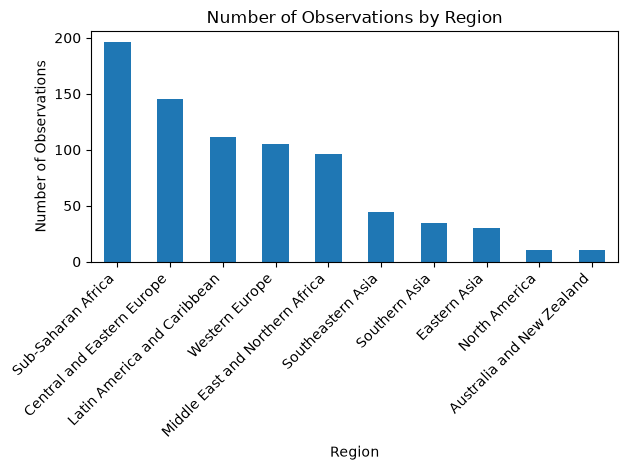

In [230]:
# bar plot of observations per region
df["region"].value_counts().plot(kind="bar")

plt.title("Number of Observations by Region")
plt.xlabel("Region")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The regional frequencies are not evenly distributed. "Sub-Saharan Africa" contains the largest number of observations, while "North America" and "Australia and New Zealand" contain considerably fewer.

#### 5.2.2 Central Tendency and Spread

The descriptive statistics below display the mean, median (50th percentile), and standard deviation for each continuous variable. Also the minimum, maximum and quartiles help us understand the spread of each variable in our dataset.

In [231]:
# continuous variables used in the analysis
continuous_variables = ["happiness_score", "gdp_per_capita", "social_support", "healthy_life_expectancy", "freedom", "corruption_perception", "generosity"]

# summary statistics for the continuous variables
df[continuous_variables].describe().round(3)

,happiness_score,gdp_per_capita,social_support,healthy_life_expectancy,freedom,corruption_perception,generosity
count,782.000,782.000,782.000,782.000,782.000,781.000,782.000
mean,5.379,0.916,1.078,0.612,0.411,0.125,0.219
std,1.127,0.407,0.330,0.248,0.153,0.106,0.122
min,2.693,0.000,0.000,0.000,0.000,0.000,0.000
25%,4.510,0.606,0.869,0.440,0.310,0.054,0.130
50%,5.322,0.982,1.125,0.647,0.431,0.091,0.202
75%,6.190,1.236,1.327,0.808,0.531,0.156,0.279
max,7.769,2.096,1.644,1.141,0.724,0.552,0.838


In [232]:
# additional measures to show the spread
additional_statistics = pd.DataFrame({
    "variance": df[continuous_variables].var(),
    "min": df[continuous_variables].min(),
    "max": df[continuous_variables].max(),
    "range": df[continuous_variables].max() - df[continuous_variables].min()
})
additional_statistics.round(3)

,variance,min,max,range
happiness_score,1.271,2.693,7.769,5.076
gdp_per_capita,0.166,0.000,2.096,2.096
social_support,0.109,0.000,1.644,1.644
healthy_life_expectancy,0.062,0.000,1.141,1.141
freedom,0.023,0.000,0.724,0.724
corruption_perception,0.011,0.000,0.552,0.552
generosity,0.015,0.000,0.838,0.838


As we can see from the table, the average happiness score is 5.38 (SD = 1.13) and is close to the median of 5.32, while the six factor contributions vary considerably in their numerical ranges and should therefore not be compared directly based on absolute values.

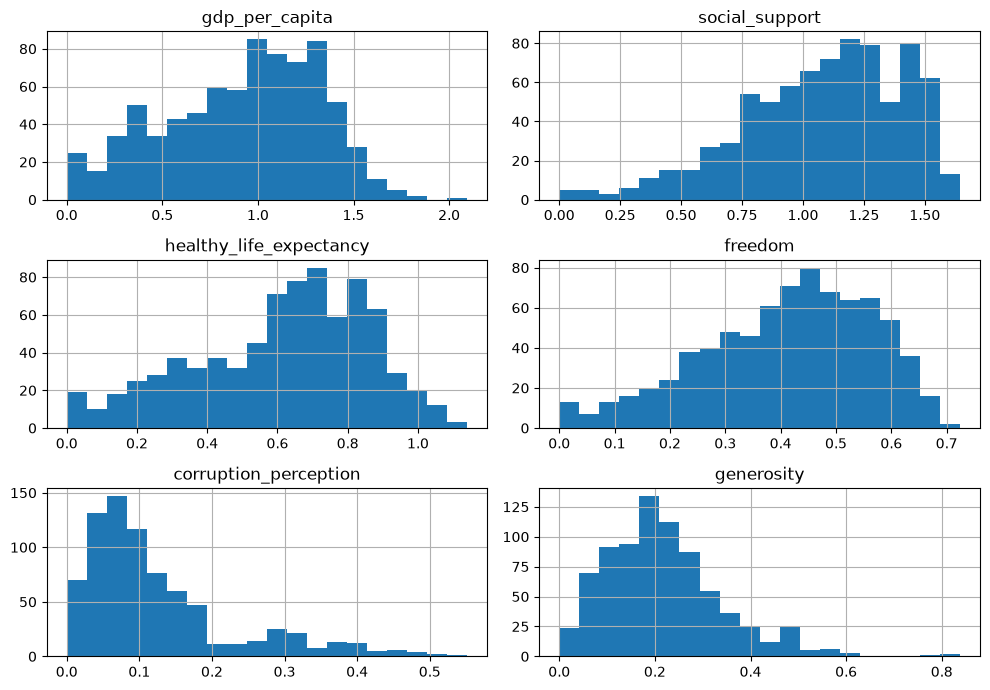

In [233]:
# distributions of the six factor contributions
factor_variables = ["gdp_per_capita","social_support","healthy_life_expectancy","freedom","corruption_perception","generosity"]

df[factor_variables].hist(figsize=(10, 7), bins=20)
plt.tight_layout()
plt.show()

The factor distributions differ noticeably in shape. GDP per capita, social support, healthy life expectancy, and freedom are relatively broadly distributed, whereas `corruption_perception` and `generosity` are more strongly concentrated at lower values with longer right tails. This is consistent with their higher positive skewness reported above.

#### 5.2.3 Distribution and Extreme Values

Next, we examine the distributions of the continuous variables and look for skewness and potential extreme values (outliers). We begin with the happiness_score, which is the main outcome variable of the analysis.

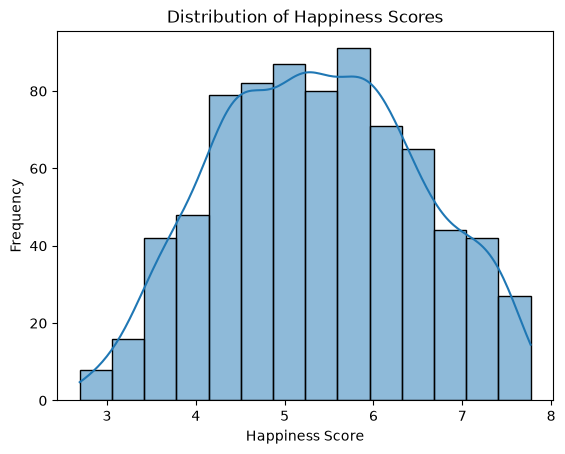

In [234]:
# distribution of happiness scores in histogram
sns.histplot(df["happiness_score"], kde=True)
plt.title("Distribution of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Frequency")
plt.show()

In [235]:
# skewness and kurtosis of the continuous variables
distribution_stats = pd.DataFrame({
    "skewness": df[continuous_variables].skew(),
    "kurtosis": df[continuous_variables].kurt()
})
distribution_stats.round(3)

,skewness,kurtosis
happiness_score,0.036,-0.761
gdp_per_capita,-0.319,-0.693
social_support,-0.685,0.158
healthy_life_expectancy,-0.501,-0.488
freedom,-0.521,-0.307
corruption_perception,1.521,1.880
generosity,1.044,2.020


Skewness measures asymmetry, so values close to **0** indicate a roughly symmetric distribution. As a  rule of thumb values between about **-0.5 and 0.5** are usually considered fairly symmetric, while values above **1** or below **-1** indicate clear skewness.

Kurtosis describes how heavy the tails of a distribution are compared with a normal distribution. Values close to **0** indicate a tail shape similar to normal, while positive values indicate heavier tails and more extreme observations.

In our data, `happiness_score` is almost perfectly symmetric (skewness = 0.036). Most other variables show only moderate skewness, while `corruption_perception` (1.521) and `generosity` (1.044) stand out as clearly positively skewed (asymmetric distribution). They also have relatively high positive kurtosis, suggesting heavier tails and more extreme high values than the other variables, as also seen in the boxplots below.

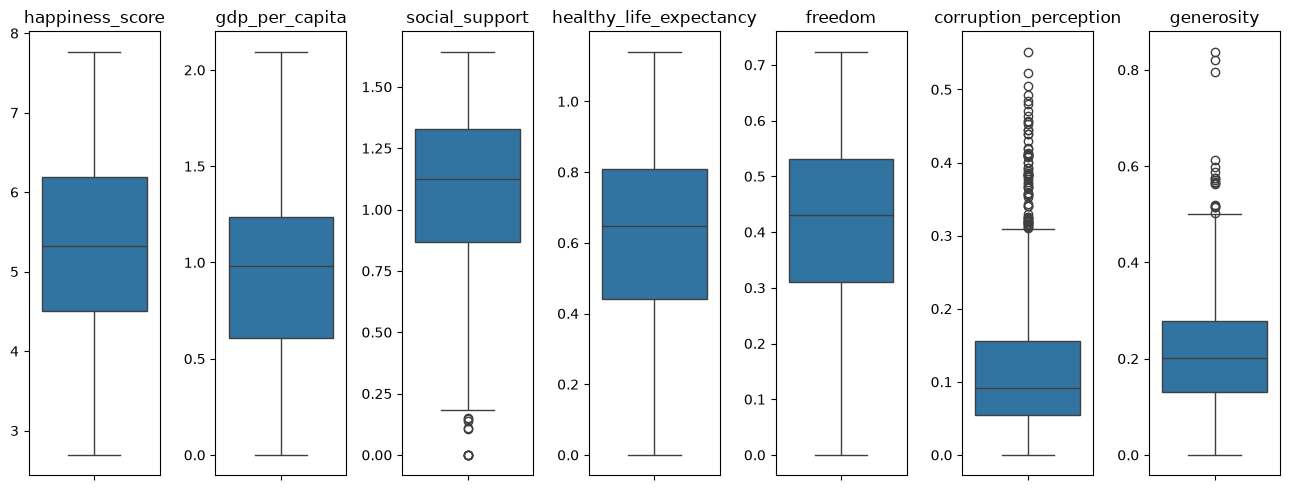

In [236]:
# one boxplot per variable
fig, axes = plt.subplots(1, 7, figsize=(13, 5))
for ax, variable in zip(axes, continuous_variables):
    sns.boxplot(y=df[variable], ax=ax)
    ax.set_title(variable)
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

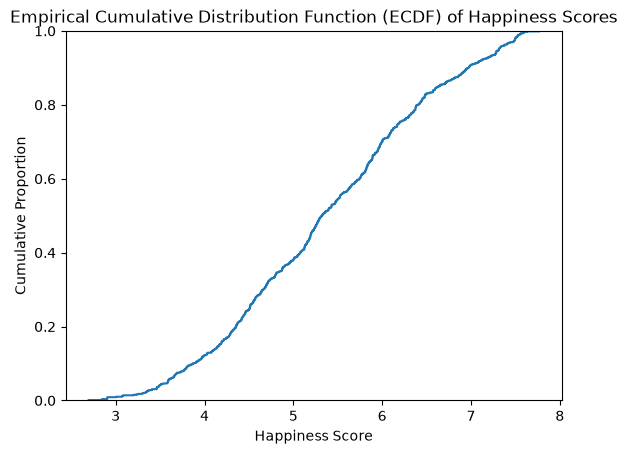

In [237]:
# empirical cumulative distribution of happiness scores
sns.ecdfplot(data=df, x="happiness_score")

plt.title("Empirical Cumulative Distribution Function (ECDF) of Happiness Scores")
plt.xlabel("Happiness Score")
plt.ylabel("Cumulative Proportion")
plt.show()

The ECDF shows the proportion of observations with a happiness score at or below a given value. For example, approximately 40% of observations have a happiness score of 5 or lower, while around 70% have a score of 6 or lower.

#### 5.2.4 Summary Statistics Table

Finally, we combine the most relevant descriptive statistics into one summary table to provide a compact overview.

In [238]:
# create a compact summary statistics table
summary_table = pd.DataFrame({
    "count": df[continuous_variables].count(),
    "mean": df[continuous_variables].mean(),
    "median": df[continuous_variables].median(),
    "std": df[continuous_variables].std(),
    "min": df[continuous_variables].min(),
    "max": df[continuous_variables].max(),
    "skewness": df[continuous_variables].skew(),
    "kurtosis": df[continuous_variables].kurt()
})

summary_table.round(3)

,count,mean,median,std,min,max,skewness,kurtosis
happiness_score,782,5.379,5.322,1.127,2.693,7.769,0.036,-0.761
gdp_per_capita,782,0.916,0.982,0.407,0.000,2.096,-0.319,-0.693
social_support,782,1.078,1.125,0.330,0.000,1.644,-0.685,0.158
healthy_life_expectancy,782,0.612,0.647,0.248,0.000,1.141,-0.501,-0.488
freedom,782,0.411,0.431,0.153,0.000,0.724,-0.521,-0.307
corruption_perception,781,0.125,0.091,0.106,0.000,0.552,1.521,1.880
generosity,782,0.219,0.202,0.122,0.000,0.838,1.044,2.020


Overall, the `happiness_score` is relatively symmetric and shows no obvious extreme outliers, while the six factor contributions differ considerably in scale and distribution. `corruption_perception` and `generosity` show the strongest positive skewness and heavier right tails.

### 5.3 Relationships between Variables

We now examine relationships between the variables. These analyses are exploratory because the factor variables are derived from the World Happiness Report's explanatory model, correlations with the happiness score should not be interpreted as independent causal evidence.

#### 5.3.1 Scatterplots

We use scatterplots to visually examine the direction and shape of the relationship between each factor contribution and the happiness score, and to identify possible non-linear patterns or extreme observations.

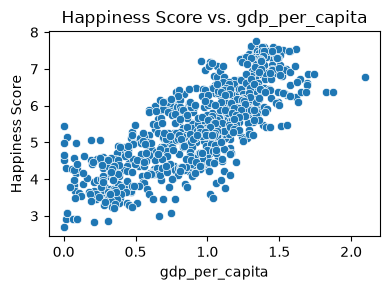

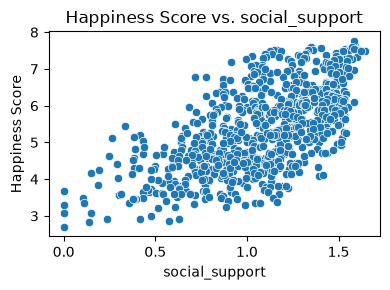

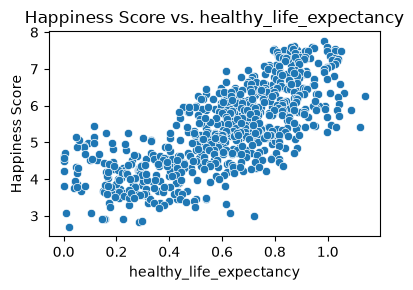

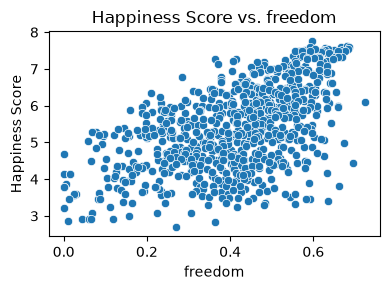

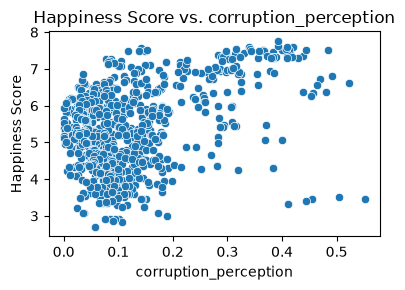

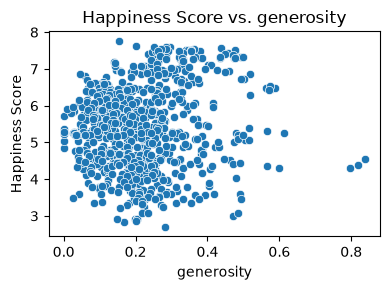

In [239]:
# scatterplots between happiness score and the six factor contributions
for variable in factor_variables:
    plt.figure(figsize=(4, 3))
    sns.scatterplot(
        data=df, x=variable, y="happiness_score"
    )
    
    plt.title(f"Happiness Score vs. {variable}")
    plt.xlabel(variable)
    plt.ylabel("Happiness Score")
    plt.tight_layout()
    plt.show()

The scatterplots suggest clear positive relationships between `happiness_score` and GDP, social support, healthy life expectancy, and freedom.

The relationship with `corruption_perception` is also generally positive but shows more clustering and several unusual observations. `generosity` shows the weakest and least clearly linear relationship with happiness.

These patterns are exploratory and will not be interpreted causally because the six factor variables are model-derived contributions.

#### 5.3.2 Covariance

Covariance indicates whether two variables tend to move in the same or opposite direction. However, its magnitude depends on the scale of the variables, making it less suitable for comparing the strength of different relationships. We therefore use covariance mainly as a preliminary measure before examining standardized correlations.

In [240]:
# covariance between happiness score and the six factor contributions
covariances = df[continuous_variables].cov()["happiness_score"].drop("happiness_score")

covariances.round(3)

gdp_per_capita             0.362
social_support             0.241
healthy_life_expectancy    0.208
freedom                    0.095
corruption_perception      0.048
generosity                 0.019
Name: happiness_score, dtype: float64

All six factor contributions show positive covariance with `happiness_score`. However, because covariance depends on the measurement scales of the variables, the magnitudes should not be directly compared.

#### 5.3.3 Pearson and Spearman Correlations

We use correlation coefficients to compare the strength and direction of the relationships on a standardized scale. Pearson correlation measures linear relationships, while Spearman correlation is based on ranks and is less sensitive to skewness, outliers, and non-linear monotonic relationships.

In [241]:
# Pearson correlations with happiness score
pearson_corr = (
    df[continuous_variables].corr(method="pearson")["happiness_score"].drop("happiness_score")
)

# Spearman correlations with happiness score
spearman_corr = (
    df[continuous_variables].corr(method="spearman")["happiness_score"].drop("happiness_score")
)

# combine both measures into a table
correlation_table = pd.DataFrame({"Pearson": pearson_corr,"Spearman": spearman_corr})
correlation_table.round(3)

,Pearson,Spearman
gdp_per_capita,0.789,0.806
social_support,0.649,0.645
healthy_life_expectancy,0.742,0.762
freedom,0.551,0.542
corruption_perception,0.398,0.273
generosity,0.138,0.122


GDP per capita and healthy life expectancy show the strongest positive associations with `happiness_score` in both Pearson and Spearman correlations, followed by social support and freedom. 

Generosity shows only a weak relationship. Pearson and Spearman correlations are generally similar, suggesting that most relationships are reasonably monotonic. The largest difference occurs for `corruption_perception` (Pearson = 0.398; Spearman = 0.273), which is consistent with the clustering, skewness, and unusual observations visible in the scatterplot.

#### 5.3.4 Correlation Heatmap

The heatmap below confirms the positive associations between `happiness_score` and most factor contributions. It also shows substantial relationships between some of the factors themselves, particularly `gdp_per_capita` and `healthy_life_expectancy` (r = 0.78). In contrast, `generosity` is only weakly related to the other factors. This indicates that the six contributions do not represent completely independent dimensions.

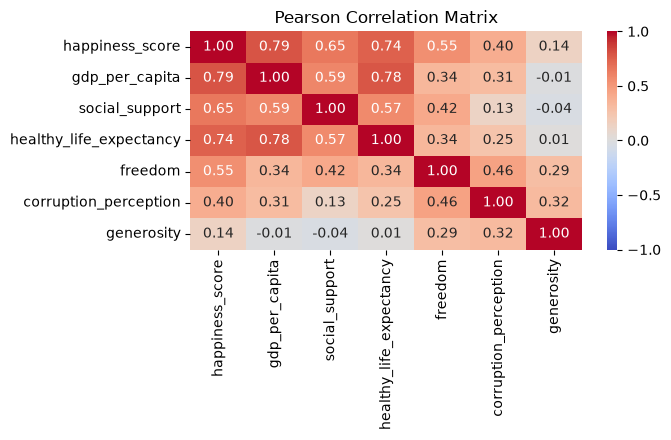

In [242]:
# Pearson correlation matrix
correlation_matrix = df[continuous_variables].corr(method="pearson")

plt.figure(figsize=(7, 4.5))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",vmin=-1,vmax=1)

plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

#### 5.3.5 Regional Patterns

To explore differences in happiness across world regions, we compare happiness_score across regions using the 2019 report edition. Using a single report edition avoids counting the same country multiple times in this regional comparison.

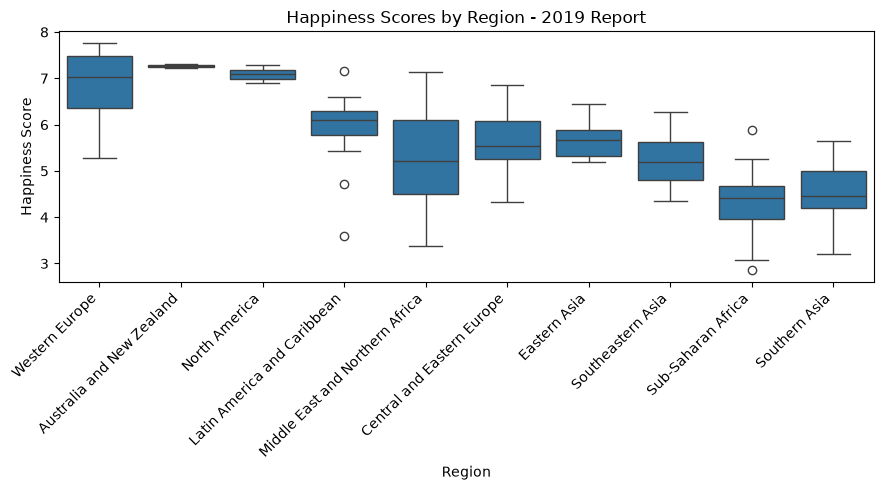

In [243]:
# use one report edition for the regional comparison
df_2019_region = df[df["year"] == 2019]

plt.figure(figsize=(9, 5))

sns.boxplot(data=df_2019_region,x="region",y="happiness_score")

plt.title("Happiness Scores by Region - 2019 Report")
plt.xlabel("Region")
plt.ylabel("Happiness Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The 2019 report shows clear regional differences in happiness scores. Western Europe, North America, and Australia and New Zealand have the highest scores, while Sub-Saharan Africa and Southern Asia tend to have lower scores. However, some regions contain only a small number of countries, so their distributions should be interpreted cautiously.

In [244]:
# create a map of happiness scores for the 2019 report
df_2019_map = df[df["year"] == 2019].copy()

fig = px.choropleth(
    df_2019_map,
    locations="country",
    locationmode="country names",
    color="happiness_score",
    hover_name="country",
    hover_data={
        "region": True,
        "happiness_score": ":.3f",
    },
    color_continuous_scale="RdYlGn",
    range_color=(2.5, 8),
    title="Happiness Scores by Country - 2019 Report"
)

fig.update_geos(showframe=False,projection_type="natural earth")
fig.update_layout(width=1000,height=500,margin=dict(l=0, r=0, t=50, b=0),coloraxis_colorbar=dict(title="Happiness<br>Score"))
fig.show()

### 5.4 Patterns across Reports

Next, we explore how reported happiness scores differ across the five World Happiness Report editions from 2015 to 2019. These comparisons are descriptive because the report editions are based on overlapping multi-year survey periods rather than independent annual measurements.

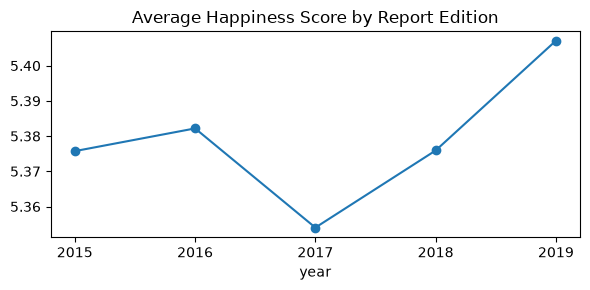

In [245]:
# average happiness score for every report edition
mean_happiness_by_year = (df.groupby("year")["happiness_score"].mean())

# plot the average happiness scores
plt.figure(figsize=(6, 3))
mean_happiness_by_year.plot(marker="o")

plt.title("Average Happiness Score by Report Edition")
plt.xticks([2015, 2016, 2017, 2018, 2019])
plt.tight_layout()
plt.show()

Average happiness scores remain relatively stable across the five report editions, ranging only from about 5.35 to 5.41. The 2017 edition has the lowest average and the 2019 edition the highest, but the differences are small and should not be interpreted as independent year-over-year changes because the underlying survey periods overlap.

#### 5.4.1 Matched 2015–2019 Subset

To examine changes in happiness over a longer period, we create a matched subset containing only countries that appear in both the 2015 and 2019 report editions. This results in 152 matched countries.

Then, we calculate the change in happiness score for each country as:
- **Happiness Change** = **Happiness Score 2019** - **Happiness Score 2015**

Positive values indicate a higher happiness score in the 2019 report, while negative values indicate a lower score.

In [246]:
# create a filtered dataset for countries present in both 2015 and 2019
scores_2015 = (df[df["year"] == 2015][["country", "region", "happiness_score"]].rename(columns={"happiness_score": "happiness_2015"}))
scores_2019 = (df[df["year"] == 2019][["country", "happiness_score"]].rename(columns={"happiness_score": "happiness_2019"}))
matched_2015_2019 = scores_2015.merge(scores_2019,on="country",how="inner")

print("Matched countries:", len(matched_2015_2019))

# print the first 5 rows of the matched dataset
matched_2015_2019.head()

Matched countries: 152


,country,region,happiness_2015,happiness_2019
0,Switzerland,Western Europe,7.587,7.480
1,Iceland,Western Europe,7.561,7.494
2,Denmark,Western Europe,7.527,7.600
3,Norway,Western Europe,7.522,7.554
4,Canada,North America,7.427,7.278


In [247]:
# change in happiness between the 2015 and 2019 report editions
matched_2015_2019["happiness_change"] = (matched_2015_2019["happiness_2019"] - matched_2015_2019["happiness_2015"])

#### 5.4.2 Distribution of Happiness Change

We now examine how much happiness scores changed between the 2015 and 2019 report editions within the matched subset of countries.

In [248]:
matched_2015_2019["happiness_change"].describe().round(3)

count    152.000
mean       0.057
std        0.507
min       -2.103
25%       -0.226
50%        0.023
75%        0.357
max        1.543
Name: happiness_change, dtype: float64

In [249]:
# count countries with positive, negative, or no change
change_counts = pd.Series({
    "Positive change": (matched_2015_2019["happiness_change"] > 0).sum(),
    "Negative change": (matched_2015_2019["happiness_change"] < 0).sum(),
    "No change": (matched_2015_2019["happiness_change"] == 0).sum()
})
change_counts

Positive change    80
Negative change    72
No change           0
dtype: int64

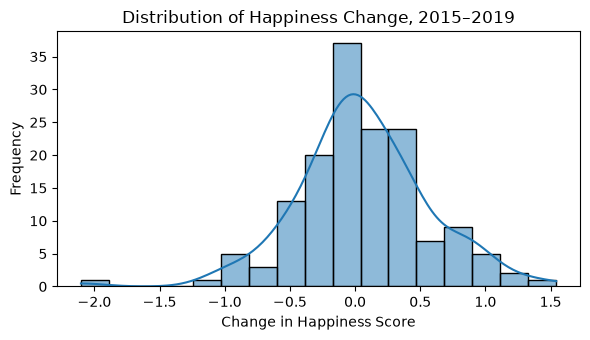

In [250]:
# plot a Histogram of the delta of happiness scores between 2015 and 2019
plt.figure(figsize=(6, 3.5))
sns.histplot(matched_2015_2019["happiness_change"],kde=True)

plt.title("Distribution of Happiness Change, 2015–2019")
plt.xlabel("Change in Happiness Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The countries in the subset show only a small average increase in happiness between the 2015 and 2019 report editions (mean change = 0.057; median = 0.023). Of the 152 countries, about half (80 countries = 53%) show a positive change and the others (72 countries = 47%) a negative change. Most changes are concentrated close to zero, although a small number of countries show outlier increases or decreases.

In [251]:
# countries with the largest increases in happiness
largest_increases = (matched_2015_2019
    .sort_values("happiness_change", ascending=False)[["country", "region", "happiness_2015", "happiness_2019", "happiness_change"]]
    .head(8)
)
largest_increases

,country,region,happiness_2015,happiness_2019,happiness_change
148,Benin,Sub-Saharan Africa,3.340,4.883,1.543
144,Cote d'Ivoire,Sub-Saharan Africa,3.655,4.944,1.289
151,Togo,Sub-Saharan Africa,2.839,4.085,1.246
101,Honduras,Latin America and Caribbean,4.788,5.860,1.072
145,Burkina Faso,Sub-Saharan Africa,3.587,4.587,1.000
100,Hungary,Central and Eastern Europe,4.800,5.758,0.958
83,Romania,Central and Eastern Europe,5.124,6.070,0.946
136,Gabon,Sub-Saharan Africa,3.896,4.799,0.903


In [252]:
# countries with the largest decreases in happiness
largest_decreases = (matched_2015_2019
    .sort_values("happiness_change")[["country", "region", "happiness_2015", "happiness_2019", "happiness_change"]]
    .head(8)
)
largest_decreases

,country,region,happiness_2015,happiness_2019,happiness_change
21,Venezuela,Latin America and Caribbean,6.810,4.707,-2.103
93,Lesotho,Sub-Saharan Africa,4.898,3.802,-1.096
82,Zambia,Sub-Saharan Africa,5.129,4.107,-1.022
111,Zimbabwe,Sub-Saharan Africa,4.610,3.663,-0.947
114,Haiti,Latin America and Caribbean,4.518,3.597,-0.921
125,Malawi,Sub-Saharan Africa,4.292,3.410,-0.882
122,Botswana,Sub-Saharan Africa,4.332,3.488,-0.844
130,Yemen,Middle East and Northern Africa,4.077,3.380,-0.697


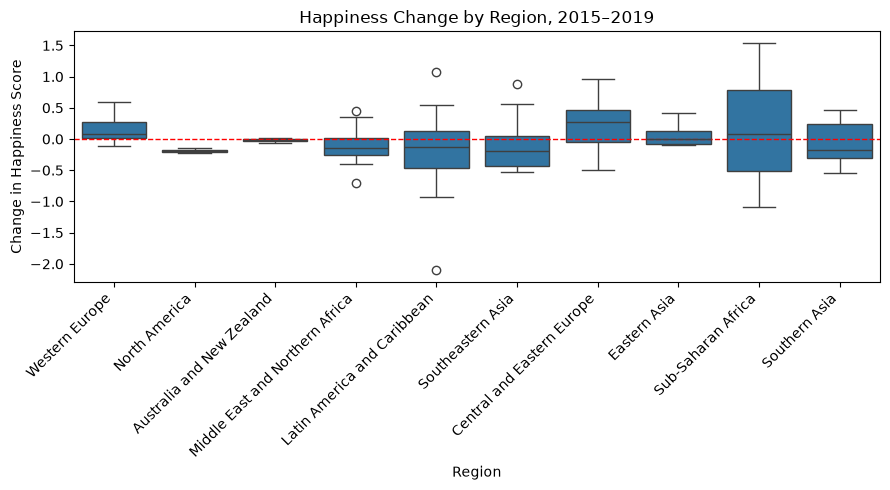

In [253]:
# boxplot of happiness change by region
plt.figure(figsize=(9, 5))
sns.boxplot(data=matched_2015_2019,x="region",y="happiness_change")
plt.axhline(0, color="red", linestyle="--", linewidth=1)

plt.title("Happiness Change by Region, 2015–2019")
plt.xlabel("Region")
plt.ylabel("Change in Happiness Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

The countries with the largest changes help to explain the tails of the distribution. Most of the largest increases and decreases in terms of happiness are found in Sub-Saharan Africa, suggesting that this region has the most volatile scores; the single largest decrease is Venezuela.

#### 5.4.3 Geographic Distribution of Happiness Change

As a final descriptive step, we visualize the geographic distribution of happiness change between the 2015 and 2019 report editions. This map helps identify whether increases and decreases are concentrated in particular parts of the world.

In [254]:
fig = px.choropleth(
    matched_2015_2019,
    locations="country",
    locationmode="country names",
    color="happiness_change",
    hover_name="country",
    hover_data={
        "region": True,
        "happiness_2015": ":.3f",
        "happiness_2019": ":.3f",
        "happiness_change": ":.3f",
    },
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    title="Geographic Distribution of Happiness Change, 2015–2019"
)

fig.update_geos(showframe=False, projection_type="natural earth")
fig.update_layout(width=1000,height=500,margin=dict(l=0, r=0, t=50, b=0),coloraxis_colorbar=dict(title="Change in<br>Happiness Score"))
fig.show()

## 6. Research Question and Hypotheses

### 6.1 Research Question

Based on the exploratory analysis, this project examines whether the configuration of a country's six happiness-contribution factors, rather than the strength of any single factor alone, is associated with subsequent changes in reported happiness.

- **Main Research Question: *Are subsequent changes (2015 to 2019) in national happiness associated with the configuration of a country’s happiness-contribution factors in 2015, specifically the balance and its weakest factor?***

Straightforward analyses of the World Happiness Report focus on whether individual factors such as economic contribution, social support, health, or freedom are associated with happiness. However, these factors are already part of the World Happiness Report's explanatory framework. Instead of reproducing these known relationships, this study takes a different perspective by examining the configuration of the six factors as a profile.

The analysis considers two related ideas. First, countries whose factors are relatively **balanced** may have a broader and potentially more resilient foundation for happiness than countries whose profiles are strongly concentrated in only a few dimensions. 
Second, even countries with relatively strong overall profiles may be constrained by **one particularly weak dimension**. This leads to a “weakest-link” perspective in which the lowest-performing factor may contain information about subsequent happiness development that is not captured by the overall average factor level.

### 6.2 Hypotheses

**Hypothesis 1: Factor Balance**
- H₀-₁: There is no association between the balance of a country's six-factor contribution profile in the 2015 report and its change in happiness between the 2015 and 2019 reports.
- H₁-₁: Countries with **more balanced** factor-contribution profiles in the 2015 report **tend to experience more favourable changes in happiness** between the 2015 and 2019 reports.

This hypothesis tests whether the configuration of strengths across multiple dimensions is associated with subsequent happiness development, rather than focusing on the absolute level of any individual factor.

**Hypothesis 2: Weakest-Link Effect**
- H₀-₂: A country's weakest factor contribution in the 2015 report is not associated with its subsequent change in happiness once the overall level of its factor contributions is taken into account.
- H₁-₂: Countries with a **stronger weakest factor** in the 2015 report tend to experience **more favourable changes in happiness** between the 2015 and 2019 reports, even after differences in overall factor-contribution level are taken into account.

Complementing the first hypothesis, the second one examines whether the lowest-performing dimension of a country may act as a limiting factor for subsequent happiness development.

### 6.3 Constructed Variables for Factor Profile Hypothesis Testing

To analyse the balance and weakest-link hypotheses, we construct three measures from the six factor contributions in the 2015 report edition. These measurements from 2015 will serve as predictors of subsequent change in happiness between 2015 and 2019.

The six contributions are measured on different numerical scales. Therefore, each factor is first standardized across the countries observed in the 2015 report using a z-score. This gives each factor a mean of approximately 0 and a standard deviation of 1 and makes the six dimensions comparable within a country's profile.

From these standardized factors, we construct our 3 measures:
- Factor Balance — the standard deviation of the six standardized factor contributions within each country. A lower value indicates a more balanced profile, while a higher value indicates greater imbalance.
- Weakest Factor — the minimum of the six standardized factor contributions. A higher value means that even the country's weakest dimension is relatively strong compared with other countries.
- Overall Factor Level — the mean of the six standardized factor contributions. This summarizes the country's general relative strength across the six dimensions and is later used as a control variable for the weakest-link hypothesis.

In [255]:
# 2015 predictors
predictors_2015 = df[df["year"] == 2015][["country", "region"] + factor_cols].copy()

# **standardize each factor** across all countries in the 2015 report
factor_means = predictors_2015[factor_cols].mean()
factor_stds = predictors_2015[factor_cols].std()

factors_z = (
    predictors_2015[factor_cols] - factor_means
) / factor_stds

# construct profile measures from standardized factors
predictors_2015["factor_balance"] = factors_z.std(axis=1)
predictors_2015["weakest_factor"] = factors_z.min(axis=1)
predictors_2015["overall_factor_level"] = factors_z.mean(axis=1)

# optional: identify which dimension is the weakest
predictors_2015["weakest_factor_name"] = (
    factors_z.idxmin(axis=1)
)

predictors_2015[["country","factor_balance","weakest_factor","overall_factor_level","weakest_factor_name"]].head(10)

,country,factor_balance,weakest_factor,overall_factor_level,weakest_factor_name
0,Switzerland,0.589150,0.469547,1.380849,generosity
1,Iceland,0.585847,-0.016427,1.134883,corruption_perception
2,Denmark,0.720930,0.821680,1.442558,generosity
3,Norway,0.369788,0.865884,1.352042,generosity
4,Canada,0.241762,1.114510,1.362142,healthy_life_expectancy
5,Finland,0.733493,-0.029881,1.164439,generosity
6,Netherlands,0.313483,1.061516,1.317610,social_support
7,Sweden,0.549025,0.989261,1.402607,generosity
8,New Zealand,0.529544,1.002287,1.498411,gdp_per_capita
9,Australia,0.243311,1.168209,1.402290,social_support


Next, we create a merged dataset containing the output variable. The 2015 profile measures are merged with the matched 2015–2019 dataset, where only countries observed in both report editions are retained, since happiness_change can only be calculated for these countries.

In [256]:
# start from the matched 2015-2019 subset
analysis_data = matched_2015_2019[[ "country","region","happiness_2015","happiness_2019","happiness_change"]].copy()

# add the profile measures constructed from the 2015 factors
analysis_data = analysis_data.merge(predictors_2015[[ "country", "factor_balance", "weakest_factor", "overall_factor_level", "weakest_factor_name"]],
    on="country",
    how="inner"
)

print("Countries in analysis dataset:", len(analysis_data))
analysis_data.head()

Countries in analysis dataset: 152


,country,region,happiness_2015,happiness_2019,happiness_change,factor_balance,weakest_factor,overall_factor_level,weakest_factor_name
0,Switzerland,Western Europe,7.587,7.480,-0.107,0.589150,0.469547,1.380849,generosity
1,Iceland,Western Europe,7.561,7.494,-0.067,0.585847,-0.016427,1.134883,corruption_perception
2,Denmark,Western Europe,7.527,7.600,0.073,0.720930,0.821680,1.442558,generosity
3,Norway,Western Europe,7.522,7.554,0.032,0.369788,0.865884,1.352042,generosity
4,Canada,North America,7.427,7.278,-0.149,0.241762,1.114510,1.362142,healthy_life_expectancy


After merging the analysis dataset now contains 152 countries with:
- **Three predictor variables** constructed from 2015 report data:
  - Factor Balance (Standard deviation of six factors)
  - Weakest Factor (minimum of six factors)
  - Overall Factor Level (mean of six factors)
- **One outcome variable**: happiness_change (2015 to 2019)

#### Descriptive Distribution of constructed Variables

To better understand the constructed profile measures, we visualize the distributions of factor_balance, weakest_factor, and overall_factor_level. These plots provide a descriptive overview before the variables are used in the hypothesis tests.

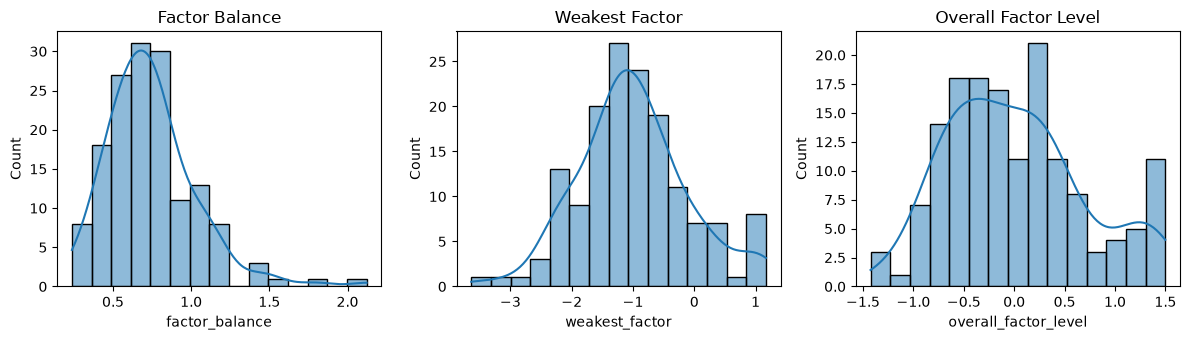

In [257]:
# distributions of the three constructed variables
constructed_vars = ["factor_balance","weakest_factor","overall_factor_level"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
titles = ["Factor Balance","Weakest Factor","Overall Factor Level"]
for ax, variable, title in zip(axes, constructed_vars, titles):
    sns.histplot(
        data=analysis_data,
        x=variable,
        bins=15,
        kde=True,
        ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel(variable)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

The constructed variables show substantial variation across the 152 matched countries. 
- factor_balance is always positive because it represents a standard deviation, with lower values indicating more balanced profiles
- weakest_factor is mostly negative, as expected when taking the minimum of six standardized factor values
- overall_factor_level is centred close to zero

## 7. Method 1: Correlation Analysis - Factor Balance

### 7.1 Why this method

Hypothesis 1 examines whether the balance of a country's factor-contribution profile in 2015 is associated with its subsequent change in happiness between the 2015 and 2019 report editions.

Both factor_balance and happiness_change are continuous variables. A correlation analysis is therefore appropriate for examining the direction and strength of their association.

factor_balance is defined as the within-country standard deviation of the six standardized factor contributions. Lower values represent more balanced profiles, while higher values represent greater imbalance. Therefore, Hypothesis 1 predicts a **negative association: countries with lower factor_balance are expected to show more favourable changes in happiness**.

We first inspect the relationship visually using a scatterplot. Pearson correlation is used to measure the linear association, while Spearman correlation is also reported because it is less sensitive to skewness, extreme observations, and deviations from linearity.

### 7.2 Visual Inspection


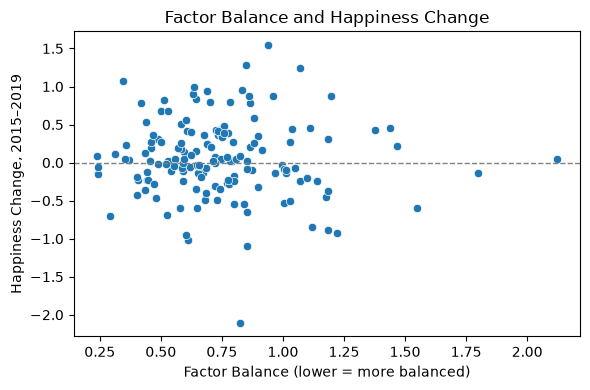

In [258]:
# relationship between factor balance and happiness change
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=analysis_data,
    x="factor_balance",
    y="happiness_change"
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.title("Factor Balance and Happiness Change")
plt.xlabel("Factor Balance (lower = more balanced)")
plt.ylabel("Happiness Change, 2015–2019")

plt.tight_layout()
plt.show()

The scatterplot **does not show a clear linear relationship** between `factor_balance` and `happiness_change`. Countries with both relatively balanced and relatively uneven profiles display positive as well as negative changes in happiness. Most observations are concentrated between factor-balance values of approximately 0.3 and 1.1, while a few more extreme observations are visible.

### 7.3 Pearson and Spearman Correlations

Based on the visual inspection, any linear association between `factor_balance` and `happiness_change` appears likely to be weak. We therefore calculate both Pearson and Spearman correlations: Pearson evaluates the linear relationship, while Spearman provides a rank-based check that is less sensitive to extreme observations and does not require a strictly linear relationship.

In [259]:
# Pearson correlation
pearson_r, pearson_p = stats.pearsonr(
    analysis_data["factor_balance"],
    analysis_data["happiness_change"]
)

# Spearman correlation
spearman_r, spearman_p = stats.spearmanr(
    analysis_data["factor_balance"],
    analysis_data["happiness_change"]
)

print(f"Pearson correlation:  r = {pearson_r:.3f}, p = {pearson_p:.3f}")
print(f"Spearman correlation: rho = {spearman_r:.3f}, p = {spearman_p:.3f}")
print(f"Sample size: n = {len(analysis_data)}")

Pearson correlation:  r = -0.037, p = 0.655
Spearman correlation: rho = -0.024, p = 0.768
Sample size: n = 152


The results provide no evidence of a meaningful association between factor balance in 2015 and subsequent happiness change. Pearson's correlation was very small and negative, while Spearman's rank correlation produced a similarly negligible result.

Although the negative direction is consistent with Hypothesis 1 because higher `factor_balance` values indicate greater imbalance, the effect is essentially zero and statistically non-significant. We therefore **fail to reject H₀-₁** and find no support for the hypothesis that more balanced factor-contribution profiles in 2015 are associated with more favourable happiness changes between the 2015 and 2019 report editions.

### 7.4 Robustness Check

As an additional robustness check, countries are divided into two equally sized groups based on the median of factor_balance. Countries below the median are classified as more balanced, while countries at or above the median are classified as less balanced.

We then compare the mean happiness_change of the two groups using a Welch independent-samples t-test. Welch's test is used because it does not require equal variances between the groups.

This analysis is secondary to the correlation test because converting a continuous variable into two groups loses information.

In [260]:
# split countries at the median factor balance
balance_median = analysis_data["factor_balance"].median()

analysis_data["balance_group"] = np.where(
    analysis_data["factor_balance"] < balance_median,
    "More balanced",
    "Less balanced"
)

# inspect group sizes and average happiness change
group_summary = (analysis_data.groupby("balance_group")["happiness_change"].agg(["count", "mean", "std"]))

print(group_summary.round(3))

               count   mean    std
balance_group                     
Less balanced     76  0.046  0.571
More balanced     76  0.067  0.437


In [261]:
more_balanced = analysis_data.loc[analysis_data["balance_group"] == "More balanced","happiness_change"]
less_balanced = analysis_data.loc[analysis_data["balance_group"] == "Less balanced","happiness_change"]

t_stat, p_value = stats.ttest_ind(
    more_balanced,
    less_balanced,
    equal_var=False
)

print(f"Welch t-test: t = {t_stat:.3f}, p = {p_value:.3f}")
print(f"More balanced: n = {len(more_balanced)}, mean = {more_balanced.mean():.3f}")
print(f"Less balanced: n = {len(less_balanced)}, mean = {less_balanced.mean():.3f}")

Welch t-test: t = 0.257, p = 0.798
More balanced: n = 76, mean = 0.067
Less balanced: n = 76, mean = 0.046


### 7.5 Conclusion on Hypothesis 1

The robustness check leads to the same conclusion as the correlation analysis. Countries in the more balanced half of the sample show an average happiness change of 0.067, compared with 0.046 for the less balanced half. The difference of approximately 0.021 happiness points is very small.

The Welch t-test produces t = 0.257 and p = 0.798. The t-statistic is close to zero, indicating that the difference between the two group means is small relative to the variability in happiness change. The high p-value means that this difference is fully consistent with the null hypothesis of no group difference.

Therefore, the group comparison provides no additional evidence in support of Hypothesis 1 and reinforces the conclusion that factor balance in 2015 is not meaningfully associated with subsequent happiness change in this dataset.


## 8. Method 2: Multiple Linear Regression - Weakest-Link Effect

### 8.1 Why this method

Hypothesis 2 examines whether a country's weakest factor in 2015 is associated with its subsequent change in happiness while taking the country's overall factor level into account.

Multiple linear regression is appropriate because happiness_change is continuous and the method allows us to estimate the association between weakest_factor and happiness_change while controlling for overall_factor_level.

The models are built incrementally. Two control variables are needed. `overall_factor_level` is required by the hypothesis itself. `happiness_2015` is required by the data: the exploratory analysis showed that countries with lower 2015 scores improved more, a pattern known as regression to the mean. Any model that omits the initial score attributes this pattern to whatever else is in the model. The primary test of Hypothesis 2 is therefore Model 3, which includes both controls; Model 4 adds region as a robustness check.

Because higher values of weakest_factor indicate a stronger weakest dimension, **Hypothesis 2 predicts a positive coefficient** for weakest_factor.

### 8.2 Incremental Regression Model comparison

To understand how the association of weakest_factor changes when additional variables are considered, we estimate a sequence of regression models, where the models are built incrementally.
- Model 1 examines the unadjusted association between `weakest_factor` and `happiness_change`.
- Model 2 adds `overall_factor_level`, the control required by the hypothesis.
- Model 3 additionally controls for `happiness_2015`. This is the primary model for Hypothesis 2.
- Model 4 additionally includes region as a categorical control, as a robustness check; it is not the primary model because several regions contain very few countries.

The models are compared based on the coefficient and statistical significance of weakest_factor, as well as overall model fit.

In [262]:
# Model 1: weakest factor only
model_1 = smf.ols(formula="happiness_change ~ weakest_factor",data=analysis_data).fit()

# Model 2: additionally control for overall factor level
model_2 = smf.ols(formula="happiness_change ~ weakest_factor + overall_factor_level",data=analysis_data).fit()

# Model 3: additionally control for overall factor level and initial happiness
model_3 = smf.ols(formula="happiness_change ~ weakest_factor + overall_factor_level + happiness_2015",data=analysis_data).fit()

# Model 4: add control for region
model_4 = smf.ols(formula="happiness_change ~ weakest_factor + overall_factor_level + happiness_2015 + C(region)",data=analysis_data).fit()

In [263]:
# compare the four models
models = {"Model 1 (weakest factor)": model_1,"Model 2 (primary H2)": model_2,"Model 3 (with initial happiness)": model_3,"Model 4 (with region)": model_4}
model_comparison = []

for name, model in models.items():
    ci = model.conf_int().loc["weakest_factor"]
    model_comparison.append({
        "Model": name,
        "Weakest Factor Coef.": model.params["weakest_factor"],
        "p-value": model.pvalues["weakest_factor"],
        "CI Lower": ci[0],
        "CI Upper": ci[1],
        "R²": model.rsquared,
        "Adjusted R²": model.rsquared_adj,
        "Model p-value": model.f_pvalue,
        "n": int(model.nobs)
    })

model_comparison = pd.DataFrame(model_comparison)

model_comparison.round(3)

,Model,Weakest Factor Coef.,p-value,CI Lower,CI Upper,R²,Adjusted R²,Model p-value,n
0,Model 1 (weakest factor),-0.022,0.639,-0.113,0.070,0.001,-0.005,0.639,152
1,Model 2 (primary H2),0.164,0.126,-0.047,0.375,0.026,0.013,0.142,152
2,Model 3 (with initial happiness),0.216,0.028,0.024,0.408,0.203,0.187,0.000,152
3,Model 4 (with region),0.208,0.032,0.018,0.398,0.309,0.250,0.000,152


In [264]:
# does each added control improve the model? (nested F-tests)
f_32, p_32, _ = model_3.compare_f_test(model_2)
f_43, p_43, _ = model_4.compare_f_test(model_3)
print(f"Model 3 vs Model 2 (adding initial happiness): F = {f_32:.2f}, p = {p_32:.4f}")
print(f"Model 4 vs Model 3 (adding region):            F = {f_43:.2f}, p = {p_43:.4f}")

Model 3 vs Model 2 (adding initial happiness): F = 32.83, p = 0.0000
Model 4 vs Model 3 (adding region):            F = 2.39, p = 0.0153


- **Model 1 (weakest factor alone)**: no association at all (β = −0.022, p = 0.639, R² = 0.001). Taken on its own, a country's weakest dimension says nothing about its later change in happiness.

- **Model 2 (adding the overall factor level)**: the coefficient turns positive (β = 0.164) but stays non-significant (p = 0.126), and the model still explains almost nothing (R² = 0.026, model p = 0.142). Note that overall_factor_level enters with a negative sign here (β = −0.271, p = 0.055): countries with stronger profiles appear to change less favourably. This is not a real effect of the profile; it is the shadow of the initial score, which is highly correlated with the overall level (r = 0.83) and is missing from the model.

- **Model 3 (adding the initial 2015 happiness score)**: this is the stage at which the picture changes. R² jumps from 0.026 to 0.203 and the nested F-test confirms the improvement (F = 32.8, p < 0.001). The initial score is by far the strongest variable (β = −0.336, p < 0.001): a country that started one point higher in 2015 changed by about 0.34 points less. Once this is accounted for, the sign of overall_factor_level flips to positive and becomes non-significant (β = 0.142, p = 0.334), and weakest_factor becomes statistically significant (β = 0.216, p = 0.028, 95% CI [0.024, 0.408]).

- **Model 4 (adding region)**: the weakest-factor coefficient is essentially unchanged (β = 0.208, p = 0.032). Region adds explanatory power (R² = 0.309, F-test p = 0.015), but it does not alter the conclusion about the weakest factor.

The weakest-factor effect therefore only becomes visible after controlling for regression to the mean, and remains stable once it does. Interpreted on the standardized scale, one standard deviation of weakest_factor (0.89) corresponds to about 0.19 points of additional happiness change over four years — a modest but not trivial effect for a 0–10 scale.

Before drawing conclusions we verify the assumptions of Model 3 and check whether these p-values survive robust standard errors and the removal of influential countries.

In [265]:
# print only summary of our model, which is the primary model for H2
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:       happiness_change   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     12.54
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           2.36e-07
Time:                        15:32:55   Log-Likelihood:                -94.617
No. Observations:                 152   AIC:                             197.2
Df Residuals:                     148   BIC:                             209.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.0806 

### 8.3 Regression Assumptions

We follow the five checks from the course: linearity, homoscedasticity, normality of the residuals, multicollinearity and independence of the errors.

#### 8.3.1 Linearity

Multiple linear regression assumes that the predictors have approximately linear relationships with the outcome. We therefore compare the actual values of `happiness_change` with the values predicted by Model 3: the points should follow a straight line without a curved pattern.

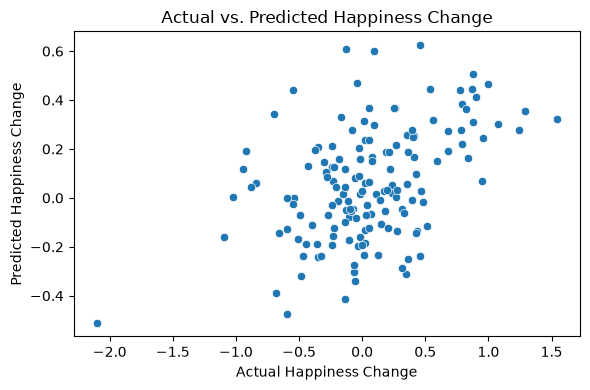

In [266]:
# predictions and residuals of the primary model
analysis_data["predictions_h2"] = model_3.predict()
analysis_data["residuals_h2"] = model_3.resid

# actual vs. predicted values
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=analysis_data,
    x="happiness_change",
    y="predictions_h2"
)

plt.xlabel("Actual Happiness Change")
plt.ylabel("Predicted Happiness Change")
plt.title("Actual vs. Predicted Happiness Change")
plt.tight_layout()
plt.show()

The actual and predicted values do not show an obvious curved pattern, although the model predicts only a relatively narrow range of happiness changes compared with the observed values. The linearity assumption therefore appears broadly acceptable, but the model has limited predictive ability, consistent with its low R².

#### 8.3.2 Homoscedasticity

Homoscedasticity requires the variance of the residuals to remain approximately constant across the fitted values. We inspect a residual-versus-fitted plot and use the Breusch–Pagan test as an additional statistical check.

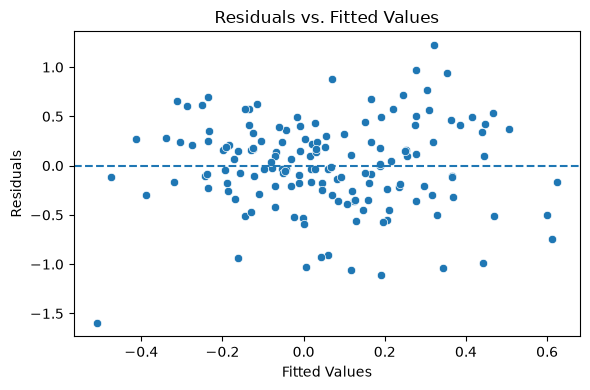

In [267]:
plt.figure(figsize=(6, 4))

sns.scatterplot(x=analysis_data["predictions_h2"],y=analysis_data["residuals_h2"]
)

plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.tight_layout()
plt.show()

In [268]:
bp_test = het_breuschpagan(model_3.resid,model_3.model.exog)
print(f"Breusch-Pagan p-value: {bp_test[1]:.3f}")

Breusch-Pagan p-value: 0.001


The residual plot shows unequal dispersion across the fitted values. This is confirmed by the Breusch–Pagan test (**p = 0.001**), which rejects the null hypothesis of constant residual variance.

The homoscedasticity assumption is therefore violated. Ordinary OLS standard errors and the resulting p-values may be unreliable. Following the approach used in the course, we therefore re-estimate the regression using **HC3 heteroscedasticity-robust standard errors**.

In [269]:
# primary H2 model with HC3 heteroscedasticity-robust standard errors
model_3_robust = smf.ols(formula="happiness_change ~ weakest_factor + overall_factor_level + happiness_2015",
    data=analysis_data
).fit(cov_type="HC3")

print(model_3_robust.summary())

                            OLS Regression Results                            
Dep. Variable:       happiness_change   R-squared:                       0.203
Model:                            OLS   Adj. R-squared:                  0.187
Method:                 Least Squares   F-statistic:                     7.818
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           7.03e-05
Time:                        15:32:56   Log-Likelihood:                -94.617
No. Observations:                 152   AIC:                             197.2
Df Residuals:                     148   BIC:                             209.3
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.0806 

With robust standard errors the coefficient of `weakest_factor` remains significant at the 5% level (p = 0.049); the comparison across all models follows in section 8.4.

#### 8.3.3 Normality of Residuals

We examine whether the regression residuals are approximately normally distributed using a histogram and a Q–Q plot. Normal residuals are particularly relevant for the reliability of conventional significance tests and confidence intervals.

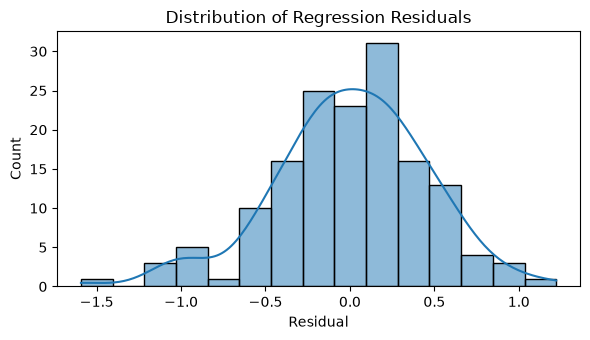

In [270]:
# histogram of residuals
plt.figure(figsize=(6, 3.5))
sns.histplot(model_3.resid, kde=True)
plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

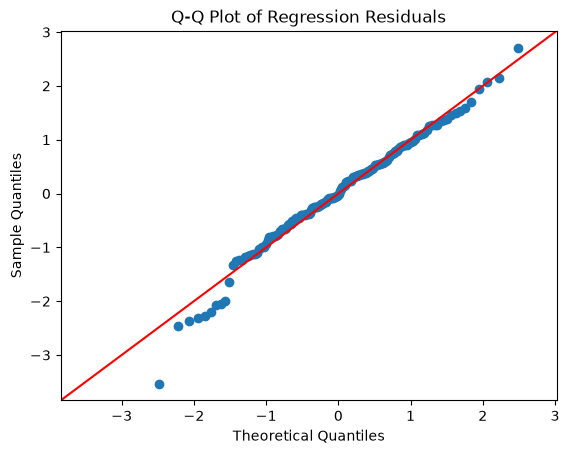

In [271]:
# Q-Q plot
sm.qqplot(model_3.resid, line="45", fit=True)
plt.title("Q-Q Plot of Regression Residuals")
plt.show()

The histogram is approximately bell-shaped and most observations in the Q–Q plot lie close to the reference line. However, noticeable deviations occur in the tails, particularly for one extreme negative residual (Venezuela).

The normality assumption is therefore not fully satisfied. With 152 observations, moderate deviations are less concerning for large-sample inference, but the extreme observations should be examined for their influence on the regression results.

#### 8.3.4 Multicollinearity

Because `weakest_factor` and `overall_factor_level` are constructed from the same six standardized factor contributions, they may contain overlapping information. We examine their correlation and Variance Inflation Factors (VIF) to assess whether multicollinearity may affect the regression estimates.

In [272]:
# correlation between predictors
analysis_data[["weakest_factor", "overall_factor_level", "happiness_2015"]].corr().round(3)

,weakest_factor,overall_factor_level,happiness_2015
weakest_factor,1.000,0.902,0.773
overall_factor_level,0.902,1.000,0.832
happiness_2015,0.773,0.832,1.000


In [273]:
X = analysis_data[["weakest_factor", "overall_factor_level", "happiness_2015"]]
X_vif = sm.add_constant(X)

vif_table = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(1, X_vif.shape[1])]   # skip the constant
})
vif_table.round(2)

,Variable,VIF
0,weakest_factor,5.43
1,overall_factor_level,7.11
2,happiness_2015,3.28


The VIF values are 5.4 for weakest_factor, 7.1 for overall_factor_level and 3.3 for happiness_2015. Two of them exceed the conservative threshold of 5, though all stay below 10. The overall factor level is the most collinear variable because it is strongly correlated with the initial happiness score (r = 0.83): countries with strong profiles are also the happiest.

This inflates its standard error, which is why it is not significant in Model 3, but it does not bias the coefficient of weakest_factor. Both controls are retained because the hypothesis requires the first and the data require the second.

#### 8.3.5 Independence of Errors

The observations should be independent of one another. Each country appears only once in the analysis dataset, which reduces the concern of repeated observations from the same country. We additionally report the Durbin–Watson statistic used in the course as a diagnostic of residual dependence.

In [274]:
dw = durbin_watson(model_3.resid)

print(f"Durbin-Watson statistic: {dw:.3f}")

Durbin-Watson statistic: 1.820


The Durbin–Watson statistic is **1.820**, which lies within the 1.5–2.5 range used in the course as an acceptable indication of independent residuals.

The independence assumption therefore does not show an obvious violation, although possible similarities between countries within the same region remain a limitation of the country-level analysis.

### 8.4 Robust Regression Results

Because the Breusch–Pagan test indicated heteroscedasticity, the four regression models are re-estimated using HC3 heteroscedasticity-robust standard errors. The regression coefficients remain unchanged, but the standard errors, confidence intervals, and p-values are adjusted to provide more reliable inference under heteroscedasticity.

In [275]:
# re-estimate all models using HC3 robust standard errors
model_1_robust = smf.ols("happiness_change ~ weakest_factor",data=analysis_data
).fit(cov_type="HC3")

model_2_robust = smf.ols("happiness_change ~ weakest_factor + overall_factor_level",data=analysis_data
).fit(cov_type="HC3")

model_3_robust = smf.ols("happiness_change ~ weakest_factor + overall_factor_level + happiness_2015",data=analysis_data
).fit(cov_type="HC3")

model_4_robust = smf.ols("happiness_change ~ weakest_factor + overall_factor_level + happiness_2015 + C(region)",data=analysis_data
).fit(cov_type="HC3")

# compare HC3-robust results
robust_models = {"Model 1": model_1_robust,"Model 2": model_2_robust,"Model 3": model_3_robust,"Model 4": model_4_robust}
robust_comparison = []
for name, model in robust_models.items():
    ci = model.conf_int().loc["weakest_factor"]

    robust_comparison.append({
        "Model": name,
        "Weakest Factor Coef.": model.params["weakest_factor"],
        "Robust p-value": model.pvalues["weakest_factor"],
        "CI Lower": ci[0],
        "CI Upper": ci[1]
    })

pd.DataFrame(robust_comparison).round(3)

,Model,Weakest Factor Coef.,Robust p-value,CI Lower,CI Upper
0,Model 1,-0.022,0.646,-0.115,0.071
1,Model 2,0.164,0.149,-0.059,0.387
2,Model 3,0.216,0.049,0.001,0.431
3,Model 4,0.208,0.067,-0.015,0.430


With HC3 standard errors the pattern is unchanged. In the primary Model 3, weakest_factor remains positive and just significant at the 5% level (β = 0.216, robust p = 0.049, 95% CI [0.001, 0.431]); in Model 4 it is borderline (β = 0.208, p = 0.067). Since Hypothesis 2 is directional, the corresponding one-tailed p-values are 0.025 and 0.034. The initial score remains highly significant in both models (p < 0.001).

#### 8.4.1 Influential Observations

In [276]:
# Cook's distance: does any single country drive the result?
influence = model_3.get_influence()
analysis_data["cooks_d"] = influence.cooks_distance[0]
print(analysis_data.sort_values("cooks_d", ascending=False)[["country", "happiness_change", "cooks_d"]].head(4).to_string(index=False))

# re-estimate the primary model without the most influential country
most_influential = analysis_data.loc[analysis_data["cooks_d"].idxmax(), "country"]
model_3_check = smf.ols("happiness_change ~ weakest_factor + overall_factor_level + happiness_2015",
                        data=analysis_data[analysis_data["country"] != most_influential]).fit(cov_type="HC3")
print(f"\nWithout {most_influential}: beta(weakest_factor) = {model_3_check.params['weakest_factor']:.3f}, "
      f"robust p = {model_3_check.pvalues['weakest_factor']:.3f}")

  country  happiness_change  cooks_d
Venezuela            -2.103 0.170756
   Rwanda            -0.131 0.087693
     Togo             1.246 0.070913
    Yemen            -0.697 0.070731

Without Venezuela: beta(weakest_factor) = 0.177, robust p = 0.090


No country exceeds the usual Cook's distance cut-off of 1, but Venezuela (change of −2.10, the largest in the sample) is clearly the most influential observation. Without it, the weakest-factor coefficient falls to 0.177 and is no longer significant at 5% (robust p = 0.09; one-tailed 0.045). The effect is in the predicted direction in every specification, but its significance depends on one extreme country.

### 8.5 Conclusion on Hypothesis 2

The primary model provides weak evidence in favour of Hypothesis 2. Once the overall factor level and, crucially, the initial happiness score are controlled for, a stronger weakest factor in 2015 is associated with a more favourable change in happiness (β = 0.216, robust p = 0.049; one-tailed p = 0.025). The estimate is stable across specifications, but its statistical significance is marginal and sensitive to the most influential country.

**We therefore reject H₀-₂** at the 5% level on the primary model, while treating the result as tentative: the confidence interval barely excludes zero, and a larger sample or a longer period would be needed to confirm the effect.

The clearest result of this section is not about the weakest factor: the strongest predictor of a country's change in happiness is where it started. This regression-to-the-mean pattern is the reason Models 1 and 2 show nothing, and any analysis of change over time must account for it.


## 9. Interpretation, Conclusion and Limitations

### 9.1 Interpretation of Findings

The analyses show that the configuration of the six factor contributions in 2015 explains little of the subsequent change in national happiness, and that the starting level explains much more.

For **Hypothesis 1**, both Pearson and Spearman correlations between factor balance and happiness change were close to zero and statistically non-significant. The additional Welch t-test also showed virtually no difference in average happiness change between more balanced and less balanced countries. The results therefore provide no support for the idea that a more balanced factor profile was associated with more favourable subsequent happiness development.

For **Hypothesis 2**, the weakest factor shows no association in the simpler models, but once the initial 2015 score is controlled for, a stronger weakest factor is associated with a more favourable change in happiness (β = 0.216, HC3 p = 0.049). The effect is stable in size across specifications, yet its significance is marginal and disappears when Venezuela, the most influential observation, is removed (p = 0.09). The results therefore provide weak, tentative support for a weakest-link effect.

The clearest finding is not about the profile at all. The strongest predictor of a country's change in happiness is its starting level: countries that were less happy in 2015 caught up, while happier countries changed less or declined. This regression-to-the-mean pattern explains about a fifth of the variation in change and is the reason why models without the initial score show no effect of the weakest factor.

### 9.2 Conclusion

The main research question asked whether subsequent changes in national happiness are associated with the configuration of a country's factor-contribution profile, specifically its balance and weakest factor.

For Hypothesis 1 we **fail to reject the null hypothesis**: factor balance shows essentially no relationship with later happiness change. For Hypothesis 2 we **reject the null hypothesis at the 5% level on the primary model**, but the evidence is weak and depends on one influential country, so we treat the weakest-link effect as tentative rather than established.

These findings suggest that the configuration of the six World Happiness Report factor contributions, as operationalized in this project, does not by itself provide a strong explanation of differences in happiness development across countries; where a country starts from matters considerably more than the shape of its profile.

### 9.3 Limitations and Possible Improvements

Several limitations should be considered when interpreting the results.

First, the six factor variables are **model-derived contributions from the World Happiness Report rather than raw measurements**. The constructed balance and weakest-factor measures therefore describe the structure of these contributions, not the underlying social and economic conditions directly.

Second, the World Happiness Report editions are based on **multi-year averages rather than independent annual observations**. Although the 2015 and 2019 editions provide a wider comparison than adjacent reports, the analysis should still be interpreted as a comparison between report editions rather than as a precise four-year longitudinal study.

Third, the balance, weakest-factor, and overall-level measures depend on the chosen **z-score standardization and operationalization**. Alternative definitions could produce different results.

Fourth, the three predictors are strongly correlated with each other (VIF of 5.4 for `weakest_factor`, 7.1 for `overall_factor_level` and 3.3 for `happiness_2015`). This inflates standard errors and makes it harder to separate their individual effects, although it does not bias the estimates.

Fifth, the regression showed heteroscedasticity, requiring HC3 robust standard errors, and the residual distribution showed deviations in the tails. These issues increase uncertainty around the regression estimates.

Sixth, the strong association between the initial score and the subsequent change is partly a statistical artefact (regression to the mean): countries with unusually high or low scores in 2015 tend to move back toward the average regardless of their profile. Controlling for the initial score addresses this only partially.

Seventh, the weakest-link result depends on a single influential observation. Without Venezuela the coefficient keeps its sign but is no longer significant at the 5% level, so the finding should be regarded as suggestive.

Finally, the study uses aggregated observational country-level data. The findings therefore cannot establish causality and should not be interpreted as relationships that necessarily apply to individuals within countries.

Future work could use raw underlying indicators, longer non-overlapping time periods, alternative definitions of factor balance, and larger longitudinal datasets to test whether the results are robust to different measurements and time horizons.

## 10. Reflection on the use of AI

We used AI tools in the project as a supporting resource. They were mainly used to help structure the analysis, help to write and review our Python code and apply what we learned in the class exercises, explain statistical concepts, and improve the clarity of written interpretations.

A particularly useful aspect of AI was the ability to question methodological choices and receive explanations of why a certain method may or may not be appropriate. For example, AI was used to discuss the construction of the balance and weakest-factor measures, the choice between statistical methods, and the interpretation of regression diagnostics such as heteroscedasticity and multicollinearity.

Examples of prompts used during the project include:
- “How can we construct a measure of how balanced a country's six happiness factors are?”
- “How can we translate our ideas of factor balance and a weakest-link effect into testable null and alternative hypotheses?”
- “Is this statistical method appropriate for testing whether factor balance is associated with happiness change?”
- “Explain this output in simple terms.”
- “Review this part for contradictions between the research question, hypotheses and the statistical outputs and interpretations.”

However, AI outputs were never treated as automatically correct. We repeatedly checked the suggestions against the course material, the dataset, and the actual statistical outputs. During the project, some initial AI suggestions had to be corrected, particularly regarding some code snippets and visualisations in the EDA, the construction of derived variables and the interpretation of regression diagnostics. While those tools helped us to gain in efficiency, this highlighted the importance of critically evaluating AI-generated recommendations rather than accepting them without verification. 

Two concrete examples: the AI-generated cleaning code initially assumed that the United Kingdom and Israel belong to the same region, which we corrected after checking the 2015 and 2016 files; and the choice of the primary regression model was revised after we compared the incremental results and recognised that omitting the initial happiness score confounds the weakest-factor effect with regression to the mean.

## 11. References

Dataset: 
Sustainable Development Solutions Network. (n.d.). World Happiness Report [Data set]. Kaggle. https://www.kaggle.com/datasets/unsdsn/world-happiness

